# Exploring color implications of KCC tailings

Looking at previous explorations of hyperspectral signals in tailings area, it looked like the coloring of patches seen in the KCC tailings area in RGB imagery captured a lot of the hyperspectral variability. Seeing that, I wanted to investigate if differentiating tailings patches based upon their color could help tease apart what minerals/compounds are leading to spectral differences (even with imagery that is not atmospherically reflected). So, I traced out those color patches on a PlanetScope image taken the same day as the Tanager image of Kolwezi (the color patches migrate noticably on the scale of one day), along with control patches of tailings water, ore pits, waste rock, and processing tanks to see if difference spectra of these areas could help get at chemistry.

What we want to know: 
* Where are the wavelength regions of largest spectral differences between visibly distinct tailings patches?
* Do these regions relate to reflectance/absorption of chemical compounds we may be looking for?

In [13]:
### Path adjustment so internal functions can be imported

import sys
import os # for file handling

# Add the parent directory to the system path
parent_dir = os.path.abspath(os.path.join(sys.path[0], ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print("Parent directory added to sys.path:", parent_dir)    

Parent directory added to sys.path: /Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/code/hyperspectral_u_sensing


In [14]:
### Function imports

import hyperspectral_u_sensing.processing.tanager_file_handling as tanager_file_handling
import hyperspectral_u_sensing.processing.hyperspectral_corrections as hyperspectral_corrections

In [15]:
### Package imports
import geopandas as gpd # for handling geospatial data
import h5py # the hyperspectral data is in hdf5 format
from rasterio.features import rasterize # to make masks from shapefiles
import matplotlib.pyplot as plt # gotta plot
import numpy as np # for numerical operations
from shapely import box 
from sklearn.decomposition import PCA
import rasterio as rio # for reading/writing geospatial raster data
import pandas as pd # for dataframes


In [16]:
### Load in tailings patches and control shapefiles

# set a base path
base_path = '/Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/drc_hyperspectral'

# sub paths for the tailings and control shapefiles
patches_subpath = 'traced_polygons/kcc_color_patches/kcc_colors.shp'
control_subpath = 'traced_polygons/control_polygons/control_polygons.shp'

# load the shapefiles
patches_gdf = gpd.read_file(os.path.join(base_path, patches_subpath))
control_gdf = gpd.read_file(os.path.join(base_path, control_subpath))
# check the shapefiles as an output
print(patches_gdf.head())
print(control_gdf.head())

    color                                           geometry
0   white  POLYGON ((25.39682 -10.70169, 25.39738 -10.701...
1   brown  POLYGON ((25.39725 -10.7004, 25.39758 -10.7006...
2  yellow  POLYGON ((25.39776 -10.69898, 25.39824 -10.698...
3   brown  POLYGON ((25.39984 -10.70218, 25.39988 -10.702...
4     tan  POLYGON ((25.40076 -10.70372, 25.40069 -10.703...
          type                                           geometry
0  tails_water  POLYGON ((25.40094 -10.69688, 25.40146 -10.696...
1      ore_pit  POLYGON ((25.42045 -10.70413, 25.41991 -10.703...
2      ore_pit  POLYGON ((25.42531 -10.7088, 25.42795 -10.7084...
3      ore_pit  POLYGON ((25.42135 -10.71627, 25.42357 -10.714...
4   waste_rock  POLYGON ((25.39167 -10.71134, 25.39229 -10.712...


In [17]:
### Load in the hyperspectral data

# sub path for the kolwezi hyperspectral data
im_subpath = 'tanager_ims_drc/commus-order_tan-ortho-radiance_20250625'
im_path = os.path.join(base_path, im_subpath)

# search through the subdirectories for hdf5 file and the metadata.json file
scene_path, metadata_path = tanager_file_handling.find_subpaths(im_path)

# load the hyperspectral data
scene_file = h5py.File(scene_path, 'r')
scene_key = tanager_file_handling.scene_key(True)
rad_array, rad_attrs = tanager_file_handling.load_radiance(scene_file, scene_key)
wavelengths = rad_attrs['wavelengths']

# print the shape of the radiance array as a check
print("Radiance array shape:", rad_array.shape)
print("Radiance array attributes:", rad_attrs)

Radiance array shape: (426, 658, 775)
Radiance array attributes: {'Unit': 'W/(m^2 sr um)', '_FillValue': np.float32(-9999.0), 'applied_radiometric_coefficients': array([0.24117877, 0.19664247, 0.12794702, 0.10599381, 0.0785861 ,
       0.06810818, 0.05935678, 0.04755091, 0.04190101, 0.03722739,
       0.03394626, 0.0303052 , 0.02826379, 0.02598685, 0.02387025,
       0.02336355, 0.02251674, 0.02208806, 0.02204469, 0.02220925,
       0.02168082, 0.02049176, 0.01993347, 0.01987995, 0.01913034,
       0.01838925, 0.01796245, 0.01744622, 0.01674083, 0.01709536,
       0.01676122, 0.01611635, 0.01537274, 0.01469532, 0.0143942 ,
       0.01404121, 0.01360779, 0.01338364, 0.01328742, 0.01275896,
       0.01256888, 0.01229605, 0.01184709, 0.01151312, 0.01140921,
       0.01112384, 0.01085087, 0.01073875, 0.01054627, 0.01030221,
       0.0100322 , 0.01017956, 0.01043109, 0.01048737, 0.01056168,
       0.01062509, 0.01038046, 0.01180799, 0.01294908, 0.01158617,
       0.01024127, 0.01051945, 0.0

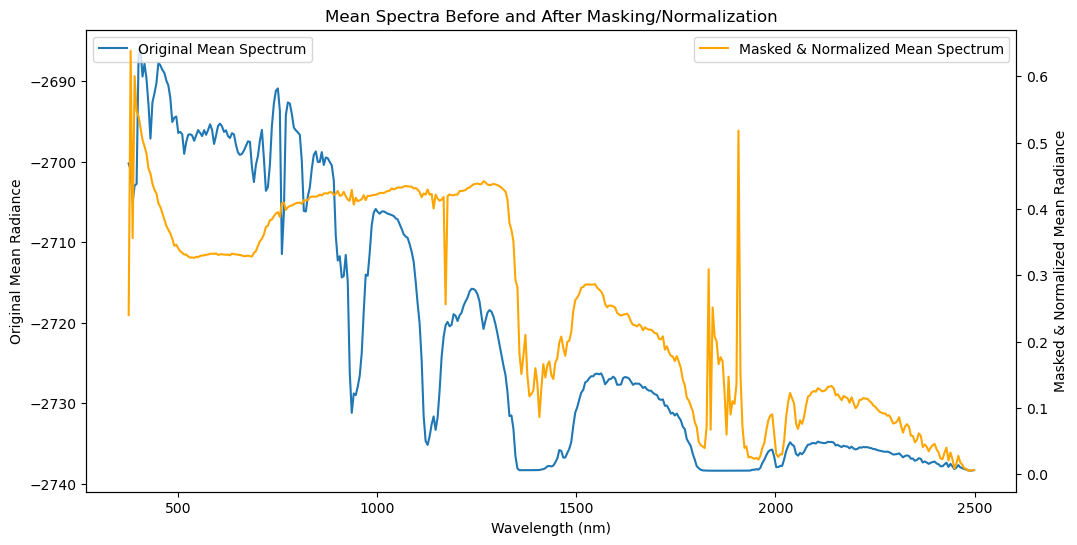

In [18]:
### normalize the radiance data, and collect the set of wavelengths that may be most atmospherically impacted

# need the mean spectrum to feed into the band function
mean_spectrum = np.mean(rad_array, axis=(1,2))

# make the bad band mask and associated bits
bad_mask = hyperspectral_corrections.tanager_bad_band_mask(rad_attrs['wavelengths'],
                          spectrum=mean_spectrum,
                          pad_nm=20)
## Not going to use the bad band mask for now, but keeping it here for future reference if needed

# take care of the no data values
no_data_val = rad_attrs['_FillValue']
no_data_mask = np.any(rad_array == no_data_val, axis=0)
rad_array[:, no_data_mask] = np.nan

# use the function to max normalize each band
rad_array_norm = hyperspectral_corrections.band_max_norm(rad_array)

# and make a new mean spectrum
normalized_mean_spectrum = np.nanmean(rad_array_norm, axis=(1,2))

# plot both mean spectra to check on a double y axis plot
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, mean_spectrum, label='Original Mean Spectrum')
# double y axis plot
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(wavelengths, normalized_mean_spectrum, color='orange', label='Masked & Normalized Mean Spectrum')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Original Mean Radiance')
ax2.set_ylabel('Masked & Normalized Mean Radiance')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Mean Spectra Before and After Masking/Normalization')
plt.show()

In [1]:
### assemble masks for the tailings patches and control color patches

# some custom functions to get geo-referencing info from the metadata
metadata = tanager_file_handling.h5_metadata(scene_file)
georef_info = tanager_file_handling.extract_georef_info(metadata)
ref_transform = tanager_file_handling.build_affine_transform(georef_info)
ref_crs = tanager_file_handling.build_crs(georef_info)
ref_shape = (georef_info['YDim'], georef_info['XDim'])
    
# double check the CRS of the polygons
if patches_gdf.crs != ref_crs:
    patches_gdf = patches_gdf.to_crs(ref_crs)

if control_gdf.crs != ref_crs:
    control_gdf = control_gdf.to_crs(ref_crs)

# also assign each polygon a unique ID, so we can track them in the rasterized mask
# start with list of unique patch colors and control types
unique_patch_colors = patches_gdf['color'].unique().tolist()
unique_control_types = control_gdf['type'].unique().tolist()

# create a mapping from color/type to unique ID
patch_color_to_id = {color: idx + 1 for idx, color in enumerate(unique_patch_colors)}
control_type_to_id = {ctype: idx + 1 for idx, ctype in enumerate(unique_control_types)}

# add a new column to each geodataframe with the unique IDs
patches_gdf['unique_id'] = patches_gdf['color'].map(patch_color_to_id)
control_gdf['unique_id'] = control_gdf['type'].map(control_type_to_id)

# rasterize the patches
patches_shapes = ((geom, value) for geom, value in zip(patches_gdf.geometry, patches_gdf.unique_id))
patches_mask = rasterize(shapes=patches_shapes,
                         out_shape=ref_shape,
                         transform=ref_transform,
                         fill=0,
                         dtype='uint8')

# rasterize the control areas
control_shapes = ((geom, value) for geom, value in zip(control_gdf.geometry, control_gdf.unique_id))
control_mask = rasterize(shapes=control_shapes,
                         out_shape=ref_shape,
                         transform=ref_transform,
                         fill=0,
                         dtype='uint8') 

# show the masks as a check
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(patches_mask, cmap='tab20')
plt.title('Patches Mask')
plt.colorbar(label='Patch Unique ID')
plt.subplot(1, 2, 2)
plt.imshow(control_mask, cmap='tab20')
plt.title('Control Mask')
plt.colorbar(label='Control Unique ID')
plt.show()

NameError: name 'tanager_file_handling' is not defined

In [20]:
### now we'll assemble a dataframe with the spectra from each patch and control area, labeled by their color/type and listing pixel locations

# initialize empty lists to hold the data
pix_color_type = []
pix_rows = []
pix_cols = []
pix_spectra = []

# loop through each patch color
for color, uid in patch_color_to_id.items():
    # find the pixel locations for this patch color
    rows, cols = np.where(patches_mask == uid)
    for r, c in zip(rows, cols):
        pix_color_type.append(color)
        pix_rows.append(r)
        pix_cols.append(c)
        pix_spectra.append(rad_array_norm[:, r, c])

# loop through each control type
for ctype, uid in control_type_to_id.items():
    # find the pixel locations for this control type
    rows, cols = np.where(control_mask == uid)
    for r, c in zip(rows, cols):
        pix_color_type.append(ctype)
        pix_rows.append(r)
        pix_cols.append(c)
        pix_spectra.append(rad_array_norm[:, r, c])

# create a dataframe from the collected data
data = {
    'color_type': pix_color_type,
    'row': pix_rows,
    'col': pix_cols,
    'spectrum': pix_spectra
}

spectra_df = pd.DataFrame(data)

# print the .head of the dataframe as a check
print(spectra_df.head())

  color_type  row  col                                           spectrum
0      white  278  382  [0.28228715, 0.7256049, 0.41603884, 0.7013257,...
1      white  278  383  [0.27433452, 0.75430703, 0.42176586, 0.726708,...
2      white  278  384  [0.26601586, 0.70732975, 0.38309512, 0.6992595...
3      white  279  378  [0.27804628, 0.75706995, 0.41511345, 0.7168538...
4      white  279  379  [0.29001915, 0.78366053, 0.43961078, 0.756242,...


In [21]:
### For some simple crossplotting, we'll do add 5 principal components to the dataframe

# stack the spectra into a 2D array for PCA
spectra_stack = np.vstack(spectra_df['spectrum'].values)

# perform PCA
pca = PCA(n_components=5)
pca_scores = pca.fit_transform(spectra_stack)

# store the pc spectra as their own variable
pc_spectra = pca.components_

# add the PCA scores to the dataframe
for i in range(pca_scores.shape[1]):
    spectra_df[f'PC{i+1}'] = pca_scores[:, i]

# print the .head of the dataframe as a check
print(spectra_df.head())

  color_type  row  col                                           spectrum  \
0      white  278  382  [0.28228715, 0.7256049, 0.41603884, 0.7013257,...   
1      white  278  383  [0.27433452, 0.75430703, 0.42176586, 0.726708,...   
2      white  278  384  [0.26601586, 0.70732975, 0.38309512, 0.6992595...   
3      white  279  378  [0.27804628, 0.75706995, 0.41511345, 0.7168538...   
4      white  279  379  [0.29001915, 0.78366053, 0.43961078, 0.756242,...   

        PC1       PC2       PC3       PC4       PC5  
0  1.751688  0.252079  0.316059  0.093131  0.082596  
1  1.852004 -0.062398  0.211017 -0.013359 -0.008786  
2  1.290315 -0.095549  0.049550 -0.081998  0.073890  
3  1.649984 -0.113009  0.247567 -0.010866  0.050737  
4  2.182077 -0.710793  0.091955 -0.156785 -0.170827  


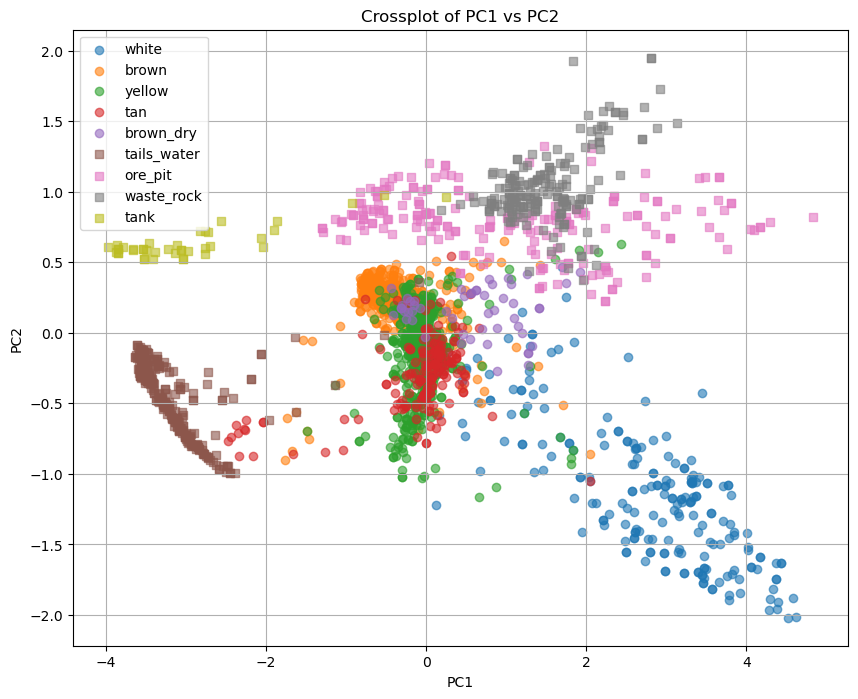

In [22]:
### cross plot any 2 pcs, colored by patch color/type, with symbols for patch vs control

# set the pcs to plot
pc_x = 'PC1' 
pc_y = 'PC2'

# make the cross plot
plt.figure(figsize=(10, 8))
for color_type in spectra_df['color_type'].unique():
    subset = spectra_df[spectra_df['color_type'] == color_type]
    this_marker = 'o' if color_type in patch_color_to_id else 's'  # circle for patches, square for controls
    plt.scatter(subset[pc_x], subset[pc_y], label=color_type, marker=this_marker, alpha=0.6)

plt.xlabel(pc_x)
plt.ylabel(pc_y)
plt.title(f'Crossplot of {pc_x} vs {pc_y}')
plt.legend()
plt.grid()
plt.show()

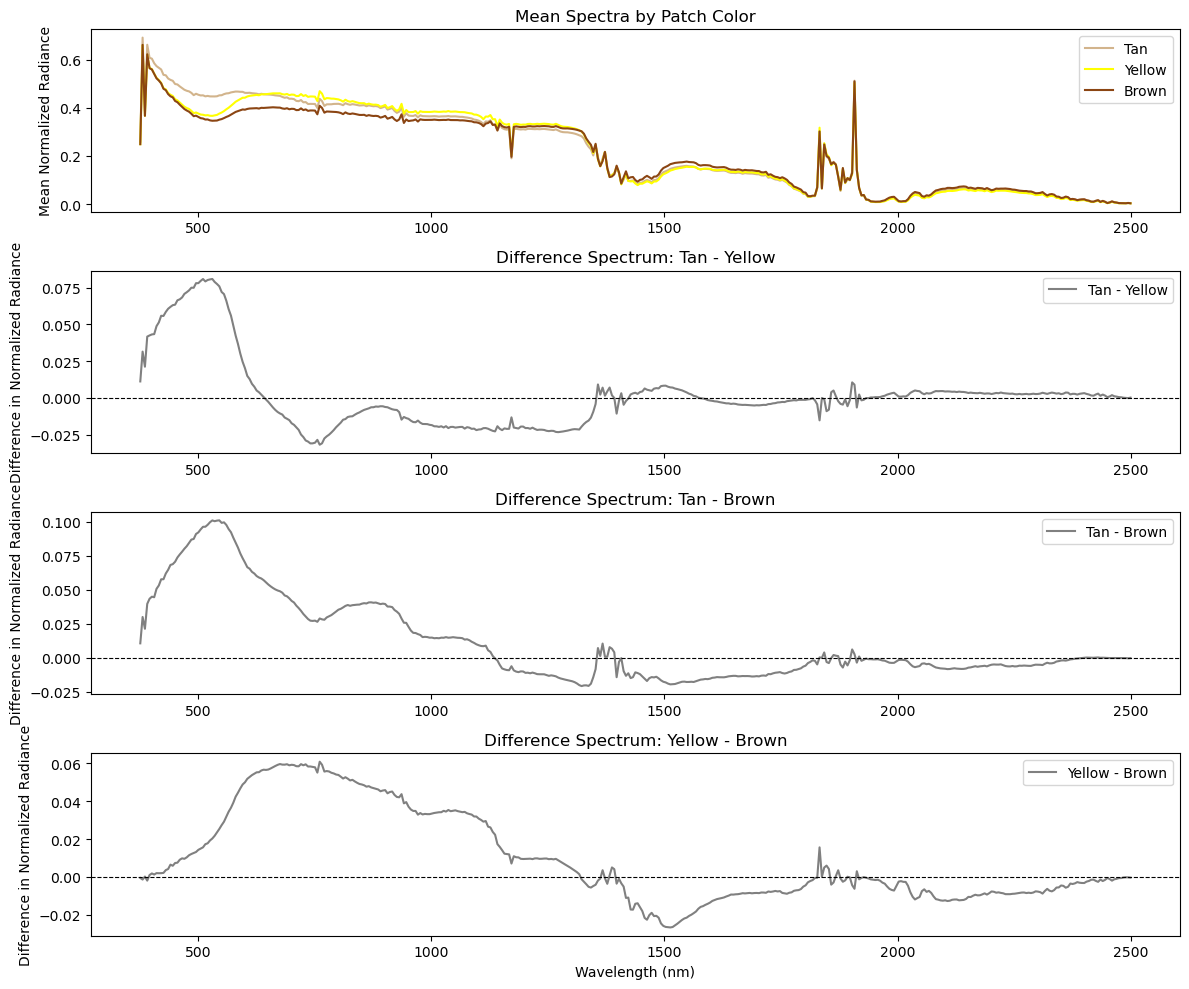

In [23]:
### difference spectra between brown, yellow, and tan patches to see what's causeing spectral differences

# get the mean spectra for each color patch
mean_spectra = {}
for color in patch_color_to_id.keys():
    subset = spectra_df[spectra_df['color_type'] == color]
    mean_spectra[color] = np.mean(np.vstack(subset['spectrum'].values), axis=0)

# manually calculate difference spectra
tan_yellow_diff = mean_spectra['tan'] - mean_spectra['yellow']
tan_brown_diff = mean_spectra['tan'] - mean_spectra['brown']
yellow_brown_diff = mean_spectra['yellow'] - mean_spectra['brown']

# plot, first with the mean spectra in the top panel
fig,axs = plt.subplots(4, 1, figsize=(12, 10))
axs[0].plot(wavelengths, mean_spectra['tan'], label='Tan', color='tan')
axs[0].plot(wavelengths, mean_spectra['yellow'], label='Yellow', color='yellow')
axs[0].plot(wavelengths, mean_spectra['brown'], label='Brown', color='saddlebrown')
axs[0].set_title('Mean Spectra by Patch Color')
axs[0].set_ylabel('Mean Normalized Radiance')
axs[0].legend() 

# now the difference spectra
axs[1].plot(wavelengths, tan_yellow_diff, label='Tan - Yellow', color='gray')
axs[1].set_title('Difference Spectrum: Tan - Yellow')
axs[1].set_ylabel('Difference in Normalized Radiance')
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[1].legend()

axs[2].plot(wavelengths, tan_brown_diff, label='Tan - Brown', color='gray')
axs[2].set_title('Difference Spectrum: Tan - Brown')
axs[2].set_ylabel('Difference in Normalized Radiance')
axs[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[2].legend()

axs[3].plot(wavelengths, yellow_brown_diff, label='Yellow - Brown', color='gray')
axs[3].set_title('Difference Spectrum: Yellow - Brown')
axs[3].set_ylabel('Difference in Normalized Radiance')
axs[3].set_xlabel('Wavelength (nm)')
axs[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[3].legend()

plt.tight_layout()
plt.show()


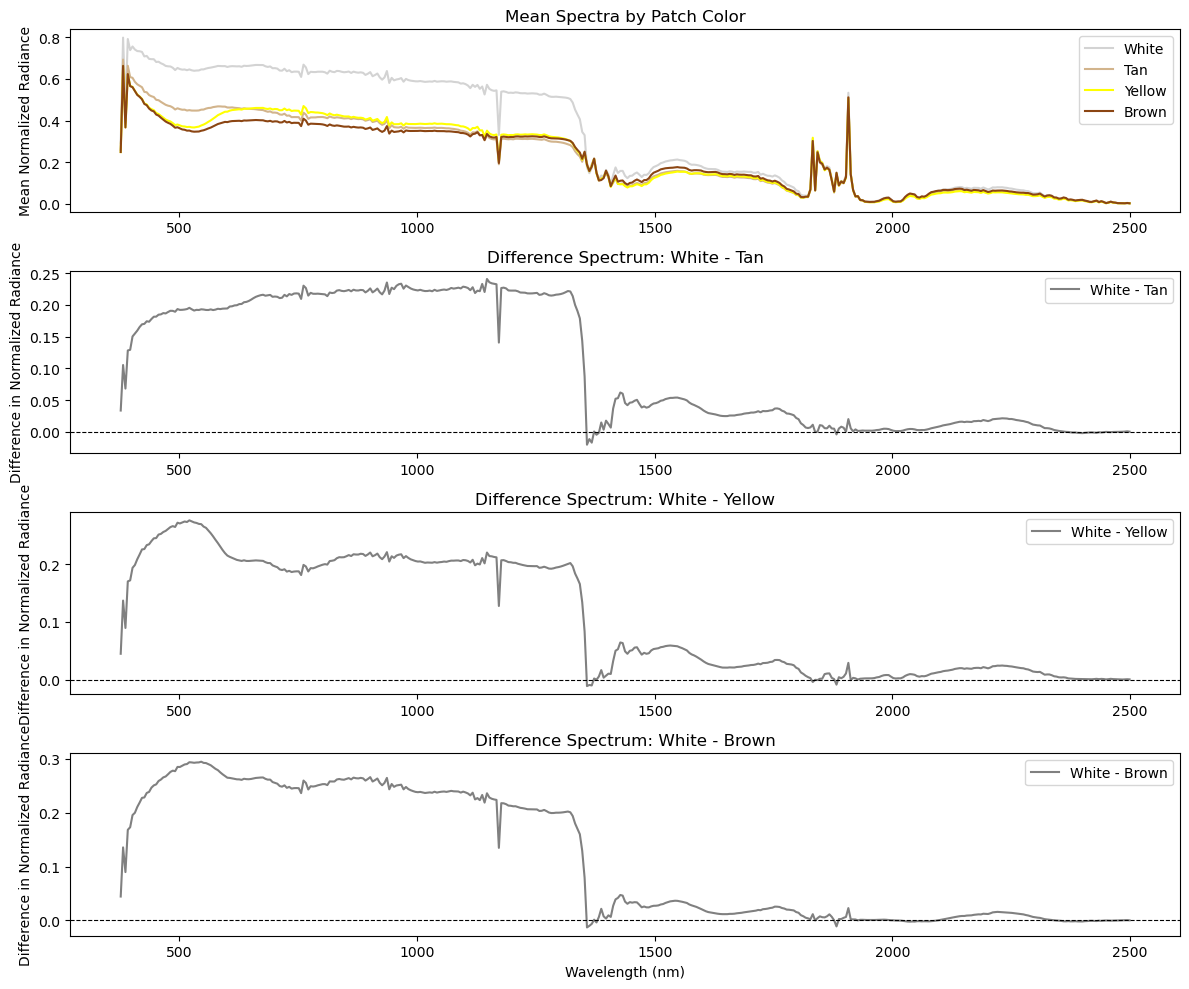

In [24]:
### similar plot, but with the diffrerences between white and all other colors

# manually calculate difference spectra
white_tan_diff = mean_spectra['white'] - mean_spectra['tan']
white_yellow_diff = mean_spectra['white'] - mean_spectra['yellow']
white_brown_diff = mean_spectra['white'] - mean_spectra['brown']

# plot, first with the mean spectra in the top panel
fig,axs = plt.subplots(4, 1, figsize=(12, 10))
axs[0].plot(wavelengths, mean_spectra['white'], label='White', color='lightgray')
axs[0].plot(wavelengths, mean_spectra['tan'], label='Tan', color='tan')
axs[0].plot(wavelengths, mean_spectra['yellow'], label='Yellow', color='yellow')
axs[0].plot(wavelengths, mean_spectra['brown'], label='Brown', color='saddlebrown')
axs[0].set_title('Mean Spectra by Patch Color')
axs[0].set_ylabel('Mean Normalized Radiance')
axs[0].legend()

# now the difference spectra
axs[1].plot(wavelengths, white_tan_diff, label='White - Tan', color='gray')
axs[1].set_title('Difference Spectrum: White - Tan')
axs[1].set_ylabel('Difference in Normalized Radiance')
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[1].legend() 

axs[2].plot(wavelengths, white_yellow_diff, label='White - Yellow', color='gray')
axs[2].set_title('Difference Spectrum: White - Yellow')
axs[2].set_ylabel('Difference in Normalized Radiance')
axs[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[2].legend() 

axs[3].plot(wavelengths, white_brown_diff, label='White - Brown', color='gray')
axs[3].set_title('Difference Spectrum: White - Brown')
axs[3].set_ylabel('Difference in Normalized Radiance')
axs[3].set_xlabel('Wavelength (nm)')
axs[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[3].legend() 

plt.tight_layout()
plt.show()

In [36]:
### We want to compare these things to some reference spectra. To do that, run the script scripts/load_all_spectra.py

from hyperspectral_u_sensing.processing import load_all_spectra
df = load_all_spectra.load_all_spectra()

# normalize the reference spectra, being every column after the first one
for col in df.columns[1:]:
    df[col] = df[col] / np.nanmax(df[col])


/var/folders/gy/tnktbqnx0rv6k4vhfbk1m2hw0000gp/T/ipykernel_59612/2606144755.py:8: RuntimeWarning: All-NaN axis encountered
  df[col] = df[col] / np.nanmax(df[col])


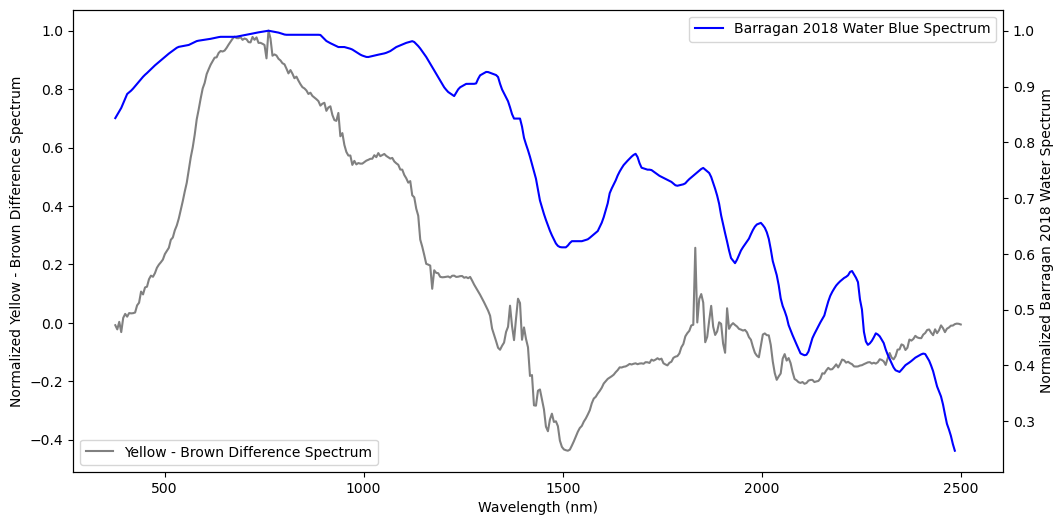

In [51]:
### one cool thing to look at is similarities between the Yellow - Brown difference spectrum and the barragan2018_water_blue spectrum

# extract the barragan2018_water_blue spectrum
water_wavelengths = df['wavelengths'].values
water_spectrum = df['barragan2018_water_blue'].values

# plot those two together, but with separate y axes
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, yellow_brown_diff / np.nanmax(np.abs(yellow_brown_diff)), label='Yellow - Brown Difference Spectrum', color='gray')
# make a double y axis plot
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(water_wavelengths, water_spectrum, label='Barragan 2018 Water Blue Spectrum', color='blue')
ax1.set_ylabel('Normalized Yellow - Brown Difference Spectrum')
ax2.set_ylabel('Normalized Barragan 2018 Water Spectrum')
ax1.set_xlabel('Wavelength (nm)')
ax1.legend(loc='lower left')
ax2.legend(loc='upper right')

plt.show()

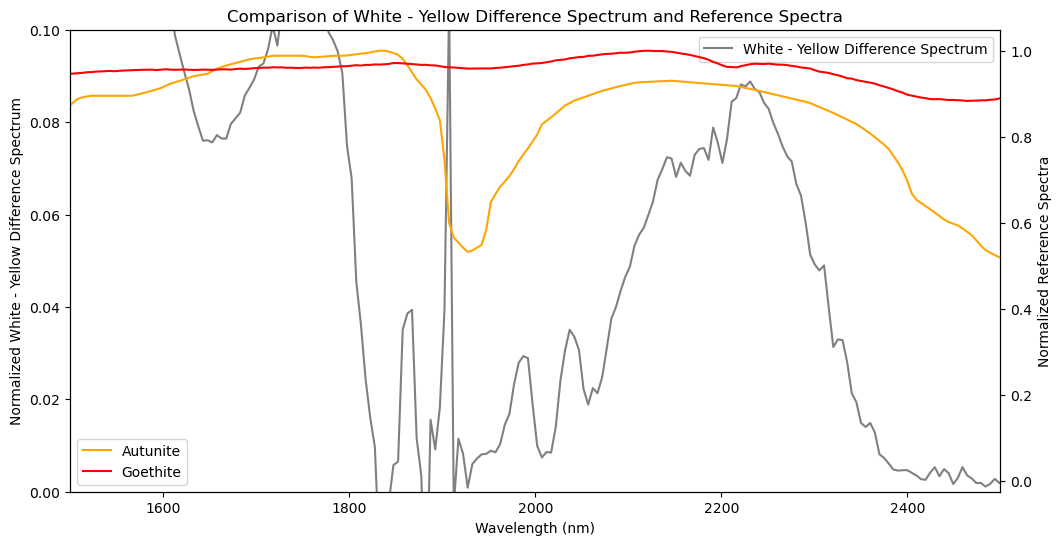

In [55]:
### and then the white - yellow difference spectrum has some interesting features too. plot it with some other reference spectra

ref_wavelengths = df['wavelengths'].values

# we'll do phosphoric acid, autunite, goethite
phosphoric_acid_spectrum = df['PhosphoricAcid'].values
autunite_spectrum = df['beiswenger2017_metaautunite'].values
goethite_spectrum = df['Goethite alpha Fe^3+O(OH)'].values

# the difference spectrum will be on one y axis, the references on the other
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, white_yellow_diff / np.nanmax(np.abs(white_yellow_diff)), label='White - Yellow Difference Spectrum', color='gray')
# make a double y axis plot
ax1 = plt.gca()
ax2 = ax1.twinx()
#ax2.plot(ref_wavelengths, phosphoric_acid_spectrum, label='Phosphoric Acid', color='green')
ax2.plot(ref_wavelengths, autunite_spectrum, label='Autunite', color='orange')
ax2.plot(ref_wavelengths, goethite_spectrum, label='Goethite', color='red')
ax1.set_ylabel('Normalized White - Yellow Difference Spectrum')
ax2.set_ylabel('Normalized Reference Spectra')
ax1.set_xlabel('Wavelength (nm)')
ax1.legend(loc='upper right')
ax2.legend(loc='lower left')
# just show wavelengths from 1500 to 2500 nm
ax1.set_xlim(1500, 2500)
# and set the ylim for ax1 to 0 to 0.5
ax1.set_ylim(0, 0.1)
plt.title('Comparison of White - Yellow Difference Spectrum and Reference Spectra')
plt.show()

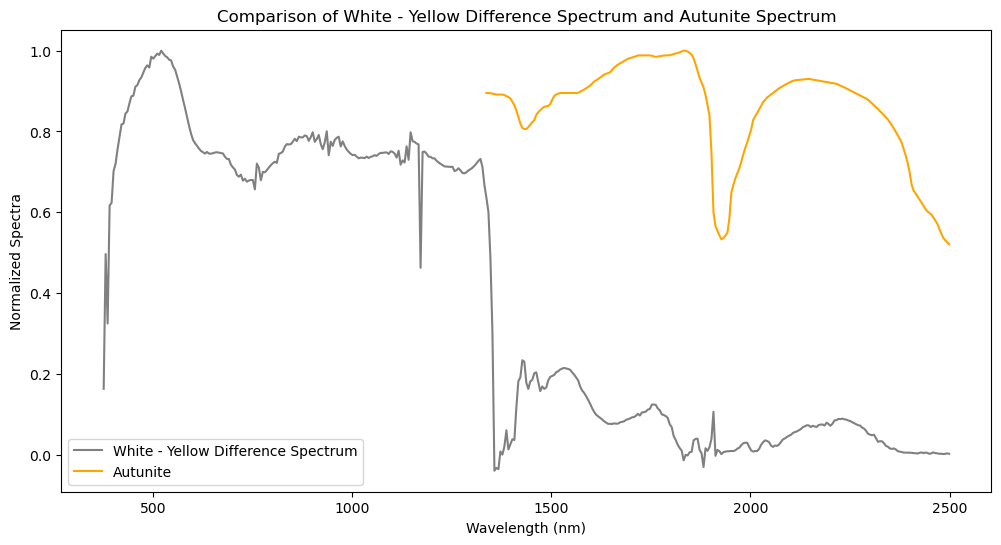

In [46]:
### plot just the metaautunite spectrum and the white - yellow difference spectrum together
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, white_yellow_diff / np.nanmax(np.abs(white_yellow_diff)), label='White - Yellow Difference Spectrum', color='gray')
plt.plot(ref_wavelengths, autunite_spectrum, label='Autunite', color='orange')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Spectra')
plt.title('Comparison of White - Yellow Difference Spectrum and Autunite Spectrum')
plt.legend()
plt.show()

In [39]:
### list out all the reference spectra columns available in the dataframe
print("Available reference spectra in the dataframe:")
for col in df.columns[1:]:
    print(col)

Available reference spectra in the dataframe:
PhosphoricAcid
UO4
UO2
UO3
AU
AUC
U3O8
Gibbsite Al(OH)_3
Siderite Fe^2+CO_3
Dolomite  CaMgCO3
Quartz SiO_2
Calcite CaCO_3
Oolitic Limestone
Azurite Cu_3(CO_3)_2(OH)_2
Magnesite MgCO_3
Dolomite CaMg(CO_3)_2
Magnetite Fe^2+Fe_2^3+O_4
Malachite Cu_2(CO_3)(OH)_2
Brucite Mg(OH)_2
Pyrolusite MnO_2
Hematite alpha Fe_2O_3
Corundum Al_2O_3
Rhodochrosite MnCO_3
Goethite alpha Fe^3+O(OH)
barragan2018_water_blue
beiswenger2017_metaautunite
